## Studing differnt dt and number of trajectories effect

In [1]:
%matplotlib ipympl
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt
from qutip import *
from IPython.display import Image, display, Math

In [2]:
#funzione per plottare in LaTex delle matrici
def array_to_latex(array, real = False, array_name = None):
    array = array.real if real else array
    matrix = ''
    for row in array:
        try:
            for number in row:
                matrix += f'{number}&'
        except TypeError:
            matrix += f'{row}&'
        matrix = matrix[:-1] + r'\\'
    if array_name != None:
        display(Math(array_name+r' = \begin{bmatrix}'+matrix+r'\end{bmatrix}'))
    else:
        display(Math(r'\begin{bmatrix}'+matrix+r'\end{bmatrix}'))

### Lindblad functions

In [3]:
def Liouvillian(H, gamma_k, L_k):
    """
    Build the Liouvillian superoperator.
    
    Parameters: - H : ndarray, Hamiltonian matrix
                - gamma_k : list, Decay rates
                - L_k : list, Jump Operators
    
    Returns: - super_L : ndarray, Liouvillian superoperator
    """    
    I = np.eye(H.shape[0])
    super_L = -1.j * (np.kron(I, H) - np.kron(H.T, I))
    
    for k in range(len(gamma_k)):
        super_L += gamma_k[k] * (np.kron(np.conj(L_k[k]), L_k[k]) - 0.5 * np.kron(I, np.conj(L_k[k]).T @ L_k[k]) - 0.5 * np.kron((np.conj(L_k[k]).T @ L_k[k]).T, I))
    
    return super_L


In [4]:
def Lindblad_evo(rho, H, gamma_k, L_k, times, method="expm", vectorized=True):
    """
    Evolution of the density matrux with the Linblad Eq.
    
    Method: - "U" -> propagator = expm(super_L * dt) (needs L_k as NumPy array)
            - "diagonal" -> diagonalizzation of the super-op. (needs L_k as NumPy array )
            - "qutip" -> using mesolve from QuTiP (needs L_k as Qobj)
    
    Vectorized: True/False to choose the output format

    Parameters: - H : Qobj or ndarray, System Hamiltonian
                - rho : Qobj or ndarray, Initial Density Matrix
                - gamma_k : list, List of Decay Rates
                - L_k : list, List of Jump Operators
                - times : array, Time array
        
    Returns : - if vectorized=True → array (N^2, Nt)
              - if vectorized=False → array (Nt, N_site, N_site)
    """
    N_shape = H.shape[0]
    dt = times[1] - times[0]
    
    # ===============================
    #   EXPM & DIAGONAL METHODS
    # ===============================
    if method in ["expm", "diagonal"]:
        # Converts Qobj in NumPy array 
        L_k_num = [L.full() if hasattr(L, "full") else np.array(L) for L in L_k]
        H_num = H.full() if hasattr(H, "full") else np.array(H)
        rho_num = rho.full() if hasattr(rho, "full") else np.array(rho)
        
        # Build up of the Lindbladian
        super_L = Liouvillian(H_num, gamma_k, L_k_num)
        
        # Vectorized intial state
        rho_vec = rho_num.reshape(N_shape*N_shape)
        
        # Result array inizialized
        rho_vec_list = np.zeros((N_shape*N_shape, len(times)), dtype=complex)
        rho_vec_list[:, 0] = rho_vec
        
        # Time Propagator
        if method == "expm":
            super_U = expm(super_L * dt)
            
            # Evolution
            for i in range(1, len(times)):
                rho_vec_list[:, i] = super_U @ rho_vec_list[:, i - 1]
            
            # Output
            if vectorized:
                return rho_vec_list  # (N_shape^2, Nt)
            else:
                return rho_vec_list.T.reshape(len(times), N_shape, N_shape)  # (Nt, N_shape, N_shape)
                
        elif method == "diagonal":             #carefull, dt could be not homogneous, so calculate it in every loop in i
            #Diagobalization of the Super-Op.
            W, V = np.linalg.eig(super_L)
            Vinv = np.linalg.inv(V)
            # Converts in NumPy array
            W = np.array(W)  #Eigenenergies
            V = np.array(V)  #Eigenvectors
            Vinv = np.array(Vinv)
            
            # Build up of the Diagonal Lindbladian
            U_diag = np.diag(np.exp(W * dt))
            super_U = U_diag

            # Initial state in diagonal basis
            rho_vec_list_diagonal = np.zeros((rho_vec_list.shape[0], len(times)), dtype=complex)
            rho_vec_list_diagonal[:, 0] = Vinv @ rho_vec_list[:, 0]
            
            # Evolution
            for i in range(1, len(times)):
                rho_vec_list_diagonal[:, i] = super_U @ rho_vec_list_diagonal[:, i - 1]

                rho_vec_list[:, i] = V @ rho_vec_list_diagonal[:, i]
                
            # Output with Eigenenergies & Eigenvectors (as NumPy array)
            if vectorized:
                return rho_vec_list, V, W  
            else:
                return rho_vec_list.T.reshape(len(times), N_shape, N_shape), V, W  
    
    # ===============================
    #   QUTIP METHOD
    # ===============================
    elif method == "qutip":
        H_qobj = Qobj(H) if not hasattr(H, "full") else H
        rho_qobj = Qobj(rho) if not hasattr(rho, "full") else rho
        
        # Build up of the collapse operators
        c_ops = []
        for g, L in zip(gamma_k, L_k):
            if g != 0:
                L_qobj = L if hasattr(L, "full") else Qobj(L)
                c_ops.append(np.sqrt(g) * L_qobj)
        
        # Evolution with mesolve
        result = mesolve(H_qobj, rho_qobj, times, c_ops=c_ops, options={"store_states": True}, )
        
        # Converts the QuTiP eigenstates in vectorized NumPy array.
        rho_vec_list = np.zeros((N_site*N_site, len(times)), dtype=complex)
        for i, rho_t in enumerate(result.states):
            rho_vec_list[:, i] = rho_t.full().reshape(N_site*N_site)
        
        # Output
        if vectorized:
            return rho_vec_list
        else:
            return rho_vec_list.T.reshape(len(times), N_site, N_site)
    
    else:
        raise ValueError("Set 'expm', 'diagonal' or 'qutip'.")

### Collisional Method functions

In [5]:
def system_Hamiltonian(N_site, E, V_pot, mode="complete"):
    """
    Build up of the System's Hamiltonian for the complete basis (ground & excited states) or only excited states.
    
    Method: - "complete"-> complete basis (ground & excited states)
            - "exc"-> excited basis (only excited states)
    
    Parameters: - E: Float, System's Site Energies (randomly generated)
                - V_pot: Float, Hopping Potential
                - N_site : int, Number of Sites
        
    Returns : System's Hamiltonian 
    """
    # =========================
    # Only Excited States Basis
    # =========================
    if mode == "exc":   
        H_sys = np.zeros((N_site, N_site), dtype=complex)
        for i in range(N_site):
            H_sys[i, i] = E[i]
        for i in range(N_site):
            for j in range(N_site):
                if i != j:
                    H_sys[i, j] = V_pot
        return H_sys
        
    # ==============
    # Complete Basis 
    # ==============    
    elif mode == "complete":   
        H_sys = np.zeros((2**N_site, 2**N_site), dtype='complex')
        
        for i in range(N_site):
            H_i = (E[i]/2) * (tensor(identity(2**i), identity(2)-sigmaz(), identity(2**(N_site-i-1)))) # g states have 0 energy and the e sites have all the energy
            #H_i = (E[i]/2) * tensor(identity(2**i), sigmaz(), identity(2**(N_site-i-1)))   # To be the same as eq II.18, where g and e state has the sameenergy but with different sign, as like the DE between the two states is equal to excoted state energy
            
            H_sys += H_i.full()

            for j in range(i+1, N_site):
               H_ij = V_pot/2 * (tensor(identity(2**i), sigmax(), identity(2**(j-i-1)), sigmax(), identity(2**(N_site-j-1))) + tensor(identity(2**i), sigmay(), identity(2**(j-i-1)), sigmay(), identity(2**(N_site-j-1))))
               H_sys += H_ij.full()
        return H_sys

    else:
        raise ValueError("mode has to be 'complete' or 'exc'")


In [6]:
def interaction_Hamiltonian_N_ancillas(N_site, c_list):   #Hamiltonian of interaction with N different ancillas, one for every site of the system
    """
    Build up of the Hamiltonian of Interaction for teh Collision System - Ancilla
       
    Parameters: - N_site : int, Number of Sites
                - c_list : list, Interaction Forces for the System - Ancilla intercation/collsion
        
    Returns : Hamiltonian of Interaction
    """
    H_int = 0   #inizialization

    for j in range(N_site):
  
        op_list = [identity(2) for _ in range(2 * N_site)]  #list of identity to be fill with the operator sigmaz & sigmax; 2N idensitty, N for the system and N fo the ancillas
        
        op_list[j] = sigmaz()      # Acts on the j site
        op_list[N_site + j] = sigmax()  # Acts on the j ancilla, with index N + j
        
        H_term = c_list[j] * tensor(op_list)  # tensor product between the element of the list
        H_int += H_term

    return H_int


In [7]:
def hamiltonian_N_ancillas(N_site, E, V_pot, c_list, method="complete"):
    """
    Generation of 3 Hamiltonians for the collision model with N ancillas:
                - H_system : system Hamiltonian
                - H_collision : interaction Hamiltonian with N ancillas
                - H_tot : complete Hamiltonian (system + collision)

    Parameters: - E: Float, System's Site Energies (randomly generated)
                - V_pot: Float, Hopping Potential
                - N_site : int, Number of Sites
                - c_list : list, Interaction Forces for the System - Ancilla intercation/collsion
    
    Method : - "complete"-> complete basis (ground & excited states)
             - "exc"-> excited basis (only excited states)

    Returns : H_system, H_collision, H_tot
    """
    
    if method == "complete":
        # ==============
        # Complete Basis 
        # ==============

        H_system_np = system_Hamiltonian(N_site, E, V_pot, mode="complete")
        H_system = Qobj(H_system_np, dims=[[2]*N_site, [2]*N_site])
        
        H_collision = interaction_Hamiltonian_N_ancillas(N_site, c_list)
        
        Id_ancillas = tensor([identity(2) for _ in range(N_site)])
        H_tot = tensor(H_system, Id_ancillas) + H_collision
        
        return H_system, H_collision, H_tot
        
    elif method == "excited":        #DA RIVEDERE COME DEFINISCO L'OPERATORE DI COLLSIONE
        # =========================
        # Only Excited States Basis
        # =========================
        
         H_system = Qobj(system_Hamiltonian(N_site, E, V_pot, mode="exc"))
        
         H_collision = 0
         for j in range(N_site):
            diag_vals = np.ones(N_site)
            diag_vals[j] = -1 
            Z_sys_j = Qobj(np.diag(diag_vals))
            
            anc_ops = [identity(2) for _ in range(N_site)]
            anc_ops[j] = sigmax()
            X_anc_j = tensor(anc_ops)
            
            H_collision += c_list[j] * tensor(Z_sys_j, X_anc_j)
        
         Id_ancillas = tensor([identity(2) for _ in range(N_site)])
         H_tot = tensor(H_system, Id_ancillas) + H_collision
        
         return H_system, H_collision, H_tot
        
    else:
         raise ValueError("method has to be 'complete' or 'excited'")

In [8]:
def evolution_operator(H, dt, backend='numpy', method='expm', hermitian=True):
    """
    Build up of the evolution operator U = exp(-i H dt) using NumPy, QuTiP, or analytic diagonalization.
   
    Parameters: - H : Qobj or ndarray, System Hamiltonian
                - dt : float, Timestep
    
    Backend : - "numpy" -> calculation and results with numpy
              - "qutip" -> calculation and results with qutip
    
    Method : - "expm"-> build up of the Matrix Exponential with expm
             - "diagonalization"->  build up of the propagater U as V @(exp(-i W dt))@ V_dag with W eigenvalues and V eigenvector of the Hamiltonian 

    Returns : Evolution Operator U
    
    """
    # Converts in Numpy array
    if backend == 'numpy':
        if isinstance(H, Qobj):
            H_np = H.full()
        else:
            H_np = np.array(H, dtype=complex)
    # Converts in QuTip array
    elif backend == 'qutip':
        if not isinstance(H, Qobj):
            H_qt = Qobj(np.array(H, dtype=complex))
        else:
            H_qt = H
    else:
        raise ValueError("backend must be 'numpy' or 'qutip'")
    
    # =====================
    # EXPONENTIAL with EXPM
    # =====================
    if method == 'expm':
        if backend == 'numpy':
            U = expm(-1j * H_np * dt)
            return U
        elif backend == 'qutip':
            original_dims = H_qt.dims
            U = (-1j * H_qt * dt).expm()
            U.dims = original_dims
            return U
    
    # ===============
    # DIAGONALIZATION
    # ===============
    elif method == 'diagonalization':
        if backend == 'numpy':
            if hermitian:
                w, v = np.linalg.eigh(H_np)
                vinv = v.conj().T
            else:
                w, v = np.linalg.eig(H_np) 
                vinv = np.linalg.inv(v)
                
            U_diag = np.diag(np.exp(-1j * w * dt))
            U = v @ U_diag @ vinv
            return U, U_diag, w, v
        
        elif backend == 'qutip':
            original_dims = H_qt.dims
            
            if hermitian:
                w, v = np.linalg.eigh(H_qt.full())
                vinv = v.conj().T
            else:
                w, v = np.linalg.eig(H_qt.full()) 
                vinv = np.linalg.inv(v)
                
            U_diag_np = np.diag(np.exp(-1j * w * dt))
            U_np = v @ U_diag_np @ vinv 
            
            U_diag = Qobj(U_diag_np, dims=original_dims)
            U = Qobj(U_np, dims=original_dims)  
            
        return U, U_diag, w, v
    else:
        raise ValueError("method must be 'expm' or 'diagonalization'")


<h1 style="color:red;">Case of Study : Exciton Dimer</h1> 

#### Evolution with $ U_{complete} $ and then trace on the ancilla

In [9]:
def compute_trace_ancilla(rho_sys_initial, rho_anc_all, U_diag, U_diag_dag, V, V_dag, times, P_10, P_01, N_site):
    """
    Compute time evolution with Trace over Ancilla and Reset, using Density Matrix formalism.; equal to Infinite Trajectories

    Parameters: - rho_sys_initial : Qobj, Initial Density Matrix
                - rho_anc_all : Qobj, Initial Density Matrix of the Ancilla expanded in the total Hilber Space (S + A)
                - U_diag: Qobj, Time Evolution Operator for the complete system (S + A) in diagonal form
                - U_diag_dag: Qobj, Adjoint operator of U_diag
                - V_diag: Qobj, Hopping Potential
                - V_diag_dag: Qobj, Adjoint operator of V_diag
                - times : array, Time array
                - N_site : int, Number of Sites                
                - P_10, P_01 : Qobj, Projection Operators on |10> & |01>
                
    Returns: - pops_complete : ndarray (N_site x len(times)),  Population evolution for each site
    """
    
    rho_sys = rho_sys_initial.copy()
    
    # Array to store the results of the evolution dimension time_step x 1
    pops_complete = np.zeros((N_site, len(times))) #population on site N
    
    #initial state
    pops_complete[0,0] = expect(P_10, rho_sys)
    pops_complete[1,0] = expect(P_01, rho_sys) 
    
    # Time Evolution
    for t in range (1, len(times)):
    
        # 1 : expansion in the system-ancilla space by tensor product
        rho_tot = tensor(rho_sys, rho_anc_all)   # I always use ancillas in their initial state! already resetted 
        rho_diag = V_dag * rho_tot * V  #diagonal form for the evolution 
        
        # 2 : Unitary evolution of the total rho
        rho_diag = U_diag * rho_diag * U_diag_dag
        rho_tot = V * rho_diag * V_dag
        
        # 3 : Partial Trace on the ancilla's degree of freedom
        rho_sys = rho_tot.ptrace([0,1]) 
    
        # 4 : Store the result of the population
        pops_complete[0,t] = expect(P_10, rho_sys)
        pops_complete[1,t] = expect(P_01, rho_sys)

    return pops_complete

#### Single trajectory

In [10]:
def compute_trajectory_wf(dt, c_CM, N_traj, N_site, times, P_10, P_01, psi_sys_initial, U_site):
    """
    Compute quantum trajectory evolution of the wave function with a collisional algorithm.
    
    Parameters: - dt : float, Time Step
                - c_CM_list : array, Collisional model Coefficients
                - N_traj : int, Number of Trajectories
                - N_site : int, Number of Sites
                - steps : int, Number of Time Steps
                - times : array, Time array
                - P_10, P_01 : Qobj, Projection Operators  on |10> & |01>
                - psi_sys_initial : Qobj, Initial Wave Function
                - U_site : Qobj, Time Evolution Operator
                       
    Returns: -  pop_traj : ndarray, Population for each trajectory (N_site x steps x N_traj)
              -  average_pop_traj : ndarray, Average population over trajectories (N_site x steps)
    """   
    # Evolution of the Wave Function
    jump_probabilities = [np.sin(c * dt)**2 for c in c_CM]   #probability to apply sigmaz to psi
    
    count = np.zeros(N_traj)
    pop_traj = np.zeros((N_site, len(times), N_traj))  #array to store the population of every site at every step of evolution for every trajectories
   
    # Costruction of the sigmaz operator for every site
    Sz_ops = []
    for idx in range(N_site):
        ops = [qeye(2) for _ in range(N_site)]
        ops[idx] = sigmaz()  # Sigmaz solo sul sito idx
        Sz_op = tensor(ops)
        Sz_ops.append(Sz_op)
        
    # Inizialization
    pop_site_1_initial = expect(P_10, psi_sys_initial)
    pop_site_2_initial = expect(P_01, psi_sys_initial)
    pop_traj[0,0,:] = pop_site_1_initial
    pop_traj[1,0,:] = pop_site_2_initial
   
    # Evolution for different Trajectories 
    for traj in range (N_traj):
        # 1 reset initial wf |01>
        psi = psi_sys_initial.copy()   
        
        # 2 Evolution in Time (starting after 1st timestep)
        for step in range(1, len(times)):
            
            psi = U_site * psi   # Evolution of wf with H_site
            
            collision_occurred = False  # Flag per tracciare se c'è stata almeno una collisione
            
            # 3 Defining the condition of the Monte Carlo - Jump for every site
            for site_index in range(N_site):
                r_site = np.random.rand() # Random number between 0 & 1
                
                if r_site < jump_probabilities[site_index]:
                    psi = Sz_ops[site_index] * psi   # apply Sigmaz 
                    psi = psi / psi.norm()   #{No renormalization, Sigmaz unitary}
                    collision_occurred = True 
            
            if not collision_occurred:
                count[traj] = count[traj] + 1
            
            # 4 Expectation Value
            pop_site_1 = expect(P_10, psi)
            pop_site_2 = expect(P_01, psi)
            pop_traj[0, step, traj] = pop_site_1
            pop_traj[1, step, traj] = pop_site_2
    
    # Average value of different trajectories
    average_pop_traj = np.mean(pop_traj, axis=2)

    return pop_traj, average_pop_traj, count

### Count number of effective collision

In [11]:
def compute_count(count, steps):
    """
    Normalization of the count of the Inneficient collision over the number of time steps and calculation of the average probability of collsion

    Parameters: - count : array, Number of Inneficient Collision (that applies identity to the system wave function)
                - steps : int, number of Time Steps
    Returns : -count : same matrix Normalized and with number of Effective Collision (that applies sigmaz to the system wave function)
              - media : average probabilty to have an Effective Collision calculated over N trajectories
    """
    
    for x in range (0, len(count)):
        count[x] /= steps
    count = 1 - count
    
    sum = 0.0
    for x in range (0, len(count)):
        sum += count[x]
    media = sum / (len(count))

    return count, media 


#### Isolated system

In [12]:
def compute_trajectory_wf_isolated(N_traj, N_site, times, P_10, P_01, psi_sys_initial, U_site):
    """
    Compute quantum trajectory evolution of the wave function with only H_system = Energy of the Site and Hopping Potential V.
    
    Parameters: - N_traj : int, Number of Trajectories
                - N_site : int, Number of Sites
                - steps : int, Number of Time Steps
                - times : array, Time array
                - P_10, P_01 : Qobj, Projection Operators on |10> & |01>
                - psi_sys_initial : Qobj, Initial Wave Function
                - U_site : Qobj, Time Evolution Operator
                       
    Returns: -  pop_traj_isolated : ndarray, Population for each trajectory (N_site x steps x N_traj)
             -  average_pop_traj_isolated : ndarray, Average population over trajectories (N_site x steps)
    """
    # Isolated system
    pop_traj_isolated = np.zeros((N_site, len(times), N_traj))
    
    # Inizialization
    pop_site_1_initial = expect(P_10, psi_sys_initial)
    pop_site_2_initial = expect(P_01, psi_sys_initial)
    
    pop_traj_isolated[0,0,:] = pop_site_1_initial
    pop_traj_isolated[1,0,:] = pop_site_2_initial
    
    # Evolution for different Trajectories 
    for traj in range (N_traj):
    
        psi = psi_sys_initial.copy()   #reset initial wf |01>
    
        # Evolution in Time (starting after 1st timestep)
        for step in range(1, len(times)):
            
            psi = U_site * psi   # Evolution of wf with H_site
                   
            pop_site_1 = expect(P_10, psi)
            pop_site_2 = expect(P_01, psi)
    
            pop_traj_isolated[0, step, traj] = pop_site_1
            pop_traj_isolated [1, step, traj] = pop_site_2
    
    # Average value of different trajectories
    average_pop_isolated = np.mean(pop_traj_isolated, axis=2) 

    return pop_traj_isolated, average_pop_isolated

#### Lindbald

In [13]:
def compute_Lindblad(H_system, rho_sys_initial, gamma_k, L_k, times):
    """
    Compute Lindblad evolution using diagonal method.
    
    Parameters: - H_system : Qobj or ndarray, System Hamiltonian
                - rho_sys_initial : Qobj or ndarray, Initial Density Matrix
                - gamma_k : list, List of Decay Rates
                - L_k : list, List of Jump Operators
                - times : array, Time array
    
    Returns: - rho_list_lindblad : ndarray, Density matrix evolution (len(times) x N_site x N_site)
             - V : ndarray, Eigenvectors of the Liouvillian
             - W : ndarray, Eigenvalues of the Liouvillian
    """
    
    rho_list_lindblad, V, W = Lindblad_evo(rho_sys_initial, H_system, gamma_k, L_k, times, method="diagonal", vectorized=False)

    return rho_list_lindblad, V, W


## Main Loop for varying $ dt $ and $ N_{traj} $

In [14]:
# System's Parameters
N_site = 2            # Number of sites
V_pot = 1.0           # Hopping Potential
E = 1.5 + np.random.randn(N_site)*0.1     #random inizialization of the system energies

# Time Evolution Parameters
dt_list = [0.01, 0.02, 0.05, 0.1 ]     # Time step
tf = 50.0    # Final Time
steps_list = [ int(tf / dt_list[i]) for i in range (len(dt_list)) ]
times_list = [ np.linspace(0, tf, int(steps_list[i])) for i in range(len(dt_list))]

N_traj_list = [100, 1000, 10000]

# Dephasing Parameter (come in MATLAB)
g_deph = 0.1       # Gamma rate

# Scaling for the collsional algorithm c = sqrt(gamma / 4dt)
c_CM_list = np.array([[np.sqrt(g_deph / (4 * dt_list[j])) for j in range(len(dt_list))] for _ in range(N_site)])  # same Coupling for the 2 sites

#Lindblad Rates
gamma_k = [g_deph, g_deph]

#array_to_latex(c_CM)
#array_to_latex(E)

In [15]:
# Initial wave function and density matrix
# System
psi_sys_initial = tensor(basis(2, 0), basis(2, 1)) # I set the population only in site 2
rho_sys_initial = ket2dm(psi_sys_initial)

# Ancilla
rho_anc_single = ket2dm(basis(2, 0)) # Pure state |0><0| for a singe ancilla
rho_anc_all = tensor([rho_anc_single for _ in range(N_site)]) #for N ancilla

# Projector for the extraction from the rho
P0 = (identity(2) + sigmaz()) / 2  # projector on |0>
P1 = (identity(2) - sigmaz()) / 2  # projector su |1>

P_00 = tensor(P0, P0) # |00><00|
P_01 = tensor(P0, P1) # |01><01|
P_10 = tensor(P1, P0) # |10><10|
P_11 = tensor(P1, P1) # |11><11|

#Lindblad Jump Operator
L_1 = P_10  # projector on |10><10|
L_2 = P_01  # projector on |01><01|
L_k = [L_1.full(), L_2.full()]

### Calculation

In [16]:
import time   # to evaluate the duration of every calculation

# Dictionary for results
results = {}

print("Starting computation for different dt and N_traj...")
print("=" * 60)

# Loop over dt
for dt_idx, dt in enumerate(dt_list):
    
    print(f"Processing dt = {dt:.4f} ({dt_idx+1}/{len(dt_list)})")
    print("-" * 60)
    
    # Extract parameters for this dt
    times = times_list[dt_idx]
    steps = steps_list[dt_idx]
    c_CM = c_CM_list[:, dt_idx]  # Column corresponding to this dt
    
    # ======================================
    # RECALCULATE HAMILTONIANS AND OPERATORS
    # ======================================
    print(f"Recalculating Hamiltonians for dt = {dt:.4f}")
    
    # Hamiltonian & U for Density Matrix (with ancillas)
    H_site, H_coll, H_tot = hamiltonian_N_ancillas(N_site, E, V_pot, c_CM, method="complete")
    
    U_tot, U_diag, w, V = evolution_operator(H_tot, dt, backend='qutip', method='diagonalization')
    U_tot = Qobj(U_tot, dims=H_tot.dims); U_diag = Qobj(U_diag, dims=H_tot.dims); U_diag_dag = U_diag.dag(); V = Qobj(V, dims=H_tot.dims); V_dag = V.dag() 
    
    # Hamiltonian & U for Wave Function (system only)
    H_system = system_Hamiltonian(N_site, E, V_pot, mode="complete")
    
    U_site, U_diag_site, w_site, V_site = evolution_operator(H_system, dt, backend='qutip', method='diagonalization', hermitian=True)
    U_site.dims = H_site.dims
    
    # ====================================
    # LINDBLAD (does not depend on N_traj)
    # ====================================
    print(f"Computing Lindblad")
    start_time = time.time()
    
    rho_list_lindblad, V_lindblad, W_lindblad = compute_Lindblad(H_system, rho_sys_initial, gamma_k, L_k, times)
    
    lindblad_time = time.time() - start_time
    print(f"Completed in {lindblad_time:.2f}s")
    
    # ========================================
    # TRACE ANCILLA (does not depend on N_traj)
    # ========================================
    print(f"Computing Trace Ancilla")
    start_time = time.time()
    
    pops_trace = compute_trace_ancilla(rho_sys_initial, rho_anc_all, U_diag, U_diag_dag, V, V_dag, times, P_10, P_01, N_site)
    
    trace_time = time.time() - start_time
    print(f"Completed in {trace_time:.2f}s")
    
    # Initialize dictionary for this dt
    results[dt] = {}
    
    # ================
    # LOOP OVER N_traj
    # ================
    for N_traj in N_traj_list:
        
        print(f"N_traj = {N_traj}")
        
        # Initialize dictionary for this N_traj
        results[dt][N_traj] = {}
        
        # ------------------------------------
        # TRAJECTORY WF (with collisions)
        # ------------------------------------
        print(f" Computing Trajectory WF")
        start_time = time.time()
        
        pop_traj, average_pop_traj, count = compute_trajectory_wf(dt, c_CM, N_traj, N_site, times, P_10, P_01, psi_sys_initial, U_site)
        
        traj_time = time.time() - start_time
        print(f"Completed in {traj_time:.2f}s")
        
        # Calculate collision statistics
        count_normalized, collision_prob = compute_count(count.copy(), steps)
        
        # ------------------------------------
        # TRAJECTORY ISOLATED (without collisions)
        # ------------------------------------
        print(f" Computing Trajectory Isolated")
        start_time = time.time()
        
        pop_traj_isolated, average_pop_isolated = compute_trajectory_wf_isolated(N_traj, N_site, times, P_10, P_01, psi_sys_initial, U_site)
        
        isolated_time = time.time() - start_time
        print(f"Completed in {isolated_time:.2f}s")
        
        # ==========================
        # SAVE RESULTS IN DICTIONARY
        # ==========================
        results[dt][N_traj] = {
            # Parameters
            'dt': dt,
            'N_traj': N_traj,
            'times': times,
            'steps': steps,
            'c_CM': c_CM,
            
            # Trace Ancilla (same for all N_traj)
            'trace_ancilla': pops_trace,
            
            # Trajectory WF
            'trajectory_wf': {
                'pop_traj': pop_traj,  # (N_site x len(times) x N_traj)
                'average_pop': average_pop_traj,  # (N_site x len(times))
                'count': count,
                'count_normalized': count_normalized,
                'collision_prob': collision_prob
            },
            
            # Trajectory Isolated
            'trajectory_isolated': {
                'pop_traj': pop_traj_isolated,
                'average_pop': average_pop_isolated
            },
            
            # Lindblad (same for all N_traj)
            'lindblad': {
                'rho_list': rho_list_lindblad,
                'V': V_lindblad,
                'W': W_lindblad
            },
            
            # Computation times
            'computation_times': {
                'lindblad': lindblad_time,
                'trace_ancilla': trace_time,
                'trajectory_wf': traj_time,
                'trajectory_isolated': isolated_time
            }
        }
        
        print(f" Results saved in results[{dt}][{N_traj}]")

print("\n" + "=" * 60)
print("COMPUTATION COMPLETED!")
print(f" Results saved for:")
print(f"   - {len(dt_list)} dt values: {dt_list}")
print(f"   - {len(N_traj_list)} N_traj values: {N_traj_list}")
print("=" * 60)

Starting computation for different dt and N_traj...
Processing dt = 0.0100 (1/4)
------------------------------------------------------------
Recalculating Hamiltonians for dt = 0.0100
Computing Lindblad
Completed in 0.02s
Computing Trace Ancilla
Completed in 0.78s
N_traj = 100
 Computing Trajectory WF
Completed in 3.57s
 Computing Trajectory Isolated
Completed in 2.71s
 Results saved in results[0.01][100]
N_traj = 1000
 Computing Trajectory WF
Completed in 33.72s
 Computing Trajectory Isolated
Completed in 26.31s
 Results saved in results[0.01][1000]
N_traj = 10000
 Computing Trajectory WF
Completed in 353.27s
 Computing Trajectory Isolated
Completed in 263.64s
 Results saved in results[0.01][10000]
Processing dt = 0.0200 (2/4)
------------------------------------------------------------
Recalculating Hamiltonians for dt = 0.0200
Computing Lindblad
Completed in 0.01s
Computing Trace Ancilla
Completed in 0.37s
N_traj = 100
 Computing Trajectory WF
Completed in 1.71s
 Computing Trajecto

In [20]:
import pickle
import os

# Crea una cartella per i risultati (opzionale)
results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

# Salva il dizionario
filename = os.path.join(results_dir, "results_dt_Ntraj.pkl")

with open(filename, 'wb') as f:
    pickle.dump(results, f)

print(f"✅ Results saved to: {filename}")
print(f"📊 File size: {os.path.getsize(filename) / (1024**2):.2f} MB")

✅ Results saved to: results/results_dt_Ntraj.pkl
📊 File size: 3052.63 MB


## Plot

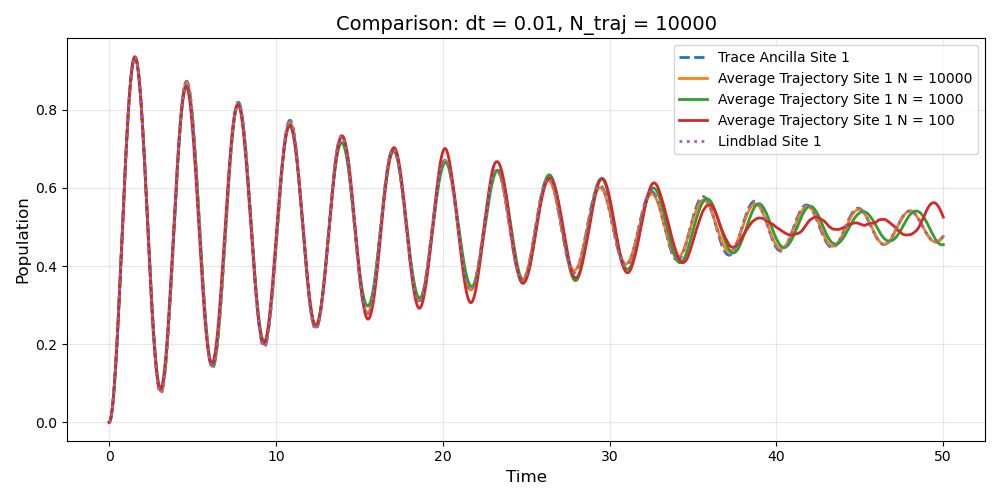

In [19]:
# Scegli quali dt e N_traj vuoi plottare
dt_plot = 0.01  # oppure 0.02, 0.05, 0.1
N_traj_plot_10000 = 10000  # oppure 1000
N_traj_plot_1000 = 1000 
N_traj_plot_100 = 100 

# Estrai i dati dal dizionario
times_plot_10000 = results[dt_plot][N_traj_plot_10000]['times']
trace_pop_10000 = results[dt_plot][N_traj_plot_10000]['trace_ancilla']
average_pop_10000 = results[dt_plot][N_traj_plot_10000]['trajectory_wf']['average_pop']

times_plot_1000 = results[dt_plot][N_traj_plot_1000]['times']
trace_pop_1000 = results[dt_plot][N_traj_plot_1000]['trace_ancilla']
average_pop_1000 = results[dt_plot][N_traj_plot_1000]['trajectory_wf']['average_pop']

times_plot_100 = results[dt_plot][N_traj_plot_100]['times']
trace_pop_100 = results[dt_plot][N_traj_plot_100]['trace_ancilla']
average_pop_100 = results[dt_plot][N_traj_plot_100]['trajectory_wf']['average_pop']

rho_lindblad = results[dt_plot][N_traj_plot]['lindblad']['rho_list']

# Plot per il sito 1 (|10>)
fig01, ax = plt.subplots(figsize=(10, 5))

ax.plot(times_plot_1000, trace_pop_1000[0, :], label=r'Trace Ancilla Site 1', linewidth=2, linestyle='--')
ax.plot(times_plot_10000, average_pop_10000[0, :], label=r'Average Trajectory Site 1 N = 10000', linewidth=2)
ax.plot(times_plot_1000, average_pop_1000[0, :], label=r'Average Trajectory Site 1 N = 1000', linewidth=2)
ax.plot(times_plot_100, average_pop_100[0, :], label=r'Average Trajectory Site 1 N = 100', linewidth=2)
ax.plot(times_plot, np.real(rho_lindblad[:, 2, 2]), label=r'Lindblad Site 1', linewidth=2, linestyle=':')

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Population', fontsize=12)
ax.set_title(f'Comparison: dt = {dt_plot}, N_traj = {N_traj_plot}', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()